# Proyecto Final — IA: Entretejiendo Imaginación y Algoritmos

## Prevención de quiebres de stock en el área analítica del laboratorio mediante generación de prompts

**Autor:** Matías Drago
**Curso:** IA - Generación de Prompts (Coderhouse) — Comisión 96165

## Resumen

En el área analítica de un laboratorio clínico, el control de stock de reactivos e insumos se realiza hoy de forma manual y fragmentada, lo que genera errores recurrentes y expone al laboratorio al riesgo de quiebres de stock — quedarse sin un reactivo crítico sin previo aviso, con impacto directo en la continuidad de diagnósticos y tratamientos de pacientes. Este proyecto propone abordar ese problema mediante técnicas de Fast Prompting aplicadas sobre datos reales de consumo del equipo analizador (Cobas Pure), generando alertas tempranas por reactivo clasificadas en zonas de riesgo (verde/amarillo/rojo), y complementando la solución con una infografía tipo "semáforo de stock" generada mediante un modelo texto-imagen, pensada como mockup visual del panel de alertas para el equipo del laboratorio.

A lo largo del desarrollo se probaron y compararon tres técnicas de prompting (zero-shot, one-shot y few-shot) sobre el mismo conjunto de datos, evidenciando que fijar el criterio de riesgo mediante ejemplos mejora sustancialmente la consistencia del resultado frente a dejar que el modelo lo infiera por su cuenta — un hallazgo que valida la viabilidad técnica de la propuesta y orienta su implementación futura.

## Introducción

### Nombre del proyecto
Prevención de quiebres de stock en el área analítica del laboratorio mediante generación de prompts

### Presentación del problema
En el área analítica del laboratorio, el control de stock de reactivos e insumos se lleva de forma manual y fragmentada: cada operador carga datos en su propia planilla secundaria, y una persona consolida "a mano" hacia una planilla maestra, sin vínculo automático entre ambas. Esto genera errores recurrentes — insumos que no quedan registrados, códigos mal cargados por manipulación, descuentos de stock mal hechos por confusión de unidades — y como consecuencia, el riesgo real de un quiebre de stock (quedarse sin un reactivo crítico sin previo aviso), lo cual puede frenar la operatoria del laboratorio y afectar la entrega de resultados a pacientes.

Esto es relevante porque un quiebre de stock en un laboratorio clínico no es solo un problema logístico: impacta directamente en la continuidad del servicio (diagnósticos, tratamientos). Hoy la detección de este riesgo depende de que alguien "se dé cuenta a tiempo" revisando planillas manualmente, lo cual es propenso a error humano y no escala si se suman más analizadores o áreas.

### Desarrollo de la propuesta de solución
La solución se vincula al desarrollo de modelos de IA a través de generación de prompts que transforman los datos de consumo (ya existentes en planillas y reportes del laboratorio) en alertas tempranas y visualizaciones claras, reemplazando la revisión manual. Se trabajó en dos frentes:

- **Modelo texto-texto:** prompts que, a partir de una tabla de stock actual y ritmo de consumo, calculan los días restantes hasta agotarse cada insumo y lo clasifican en una zona de riesgo (verde/amarillo/rojo). Se aplicaron y compararon tres técnicas de Fast Prompting: zero-shot, one-shot y few-shot.
- **Modelo texto-imagen:** prompt para generar una infografía tipo "semáforo de stock", como mockup visual de cómo se vería el panel de alertas para el equipo del laboratorio.

### Justificación de la viabilidad del proyecto
- **Viabilidad técnica:** los prompts no requieren desarrollo de software adicional — se ejecutan directamente en ChatGPT (texto-texto y texto-imagen), usando como insumo datos que ya existen en los reportes del equipo analizador (formato tabular exportable a texto).
- **Recursos disponibles:** se cuenta con datos reales de consumo extraídos de los reportes "Contador de prueba detallado" del equipo Cobas Pure (mayo, junio y julio 2026), lo que evita generar datos ficticios y acelera la prueba de los prompts.
- **Tiempo:** al estar fraccionado en etapas simples e independientes (cálculo de ritmo → clasificación por zona → visualización), cada prompt se pudo probar y ajustar sin depender de que todo el proyecto estuviera terminado.

## Objetivos

- Identificar una problemática real del laboratorio y plantear una solución utilizando ChatGPT (texto-texto y texto-imagen) para la generación de alertas e infografías.
- Plantear una solución factible de implementar mediante generación de prompts, evaluando la disponibilidad real de datos y recursos del laboratorio.
- Optimizar el uso de prompts, comparando distintas técnicas de Fast Prompting para maximizar la consistencia y utilidad del resultado con la menor cantidad de consultas posible.

## Metodología

1. Extracción de datos reales de consumo desde los reportes del equipo Cobas Pure (mayo, junio y julio 2026), calculando el ritmo de consumo diario por reactivo a partir del total acumulado de determinaciones entre cortes.
2. Definición de un stock hipotético por reactivo (dato no disponible al momento del proyecto) para simular el escenario de alerta temprana sobre datos de consumo reales.
3. Diseño y ejecución manual de tres prompts (zero-shot, one-shot, few-shot) en ChatGPT sobre el mismo dataset, para calcular días restantes y clasificar cada reactivo en una zona de riesgo.
4. Comparación de los tres resultados, identificando diferencias de consistencia entre técnicas.
5. Generación de una infografía tipo "semáforo de stock" mediante un prompt texto-imagen en ChatGPT, como mockup visual de la solución.
6. Análisis de resultados y conclusiones sobre la viabilidad de escalar la propuesta.

Se optó por ejecutar los prompts de forma manual (sin llamadas a la API) dado que fue el enfoque trabajado durante el curso, minimizando además la cantidad de consultas: una consulta por técnica comparada (3 en total para texto-texto, 1 para texto-imagen), sin llamados redundantes.

## Herramientas y tecnologías

- **ChatGPT** como motor de generación de texto e imagen.
- **Técnicas de Fast Prompting aplicadas:**
  - *Zero-shot prompting:* se le pide al modelo resolver la clasificación sin ejemplos previos, dejando que infiera (o no) el criterio de riesgo.
  - *One-shot prompting:* se fija el criterio de clasificación mostrando un único ejemplo ya resuelto.
  - *Few-shot prompting:* se refuerza el criterio con tres ejemplos, uno por cada zona de riesgo, para maximizar la consistencia del modelo.
  - *Prompt texto-imagen:* se describe de forma detallada el estilo, contenido y propósito de la infografía a generar, especificando iconografía, paleta de colores y formato de panel de monitoreo.

Se descartó el uso de la API de OpenAI/DALL-E para mantener el proyecto simple y sin costo, en línea con lo trabajado durante el curso; en su lugar, los prompts se ejecutaron directamente en la interfaz de ChatGPT.

## Implementación

### Datos de partida

A partir de tres reportes del analizador (12/05/2026, 02/06/2026 y 01/07/2026) se calculó el ritmo de consumo diario de cada reactivo. Sobre esa base se definió un stock hipotético para simular el escenario de alerta temprana, dado que no se contó con el dato de stock físico real al momento de la entrega.

In [ ]:
import pandas as pd

data = {
    "Reactivo":      ["ISE NA", "CREJ2", "GLUC3", "CHOL2-A", "TRIGL", "TSH"],
    "Stock_actual":  [850, 3200, 1400, 6000, 500, 200],
    "Ritmo_consumo_dia": [108.8, 101.1, 93.7, 63.8, 9.6, 0.0],
}

df = pd.DataFrame(data)
df["Dias_restantes"] = df.apply(
    lambda row: round(row["Stock_actual"] / row["Ritmo_consumo_dia"], 1) if row["Ritmo_consumo_dia"] > 0 else None,
    axis=1
)
df

### Criterio de clasificación por zona de riesgo

| Zona | Días de cobertura |
|---|---|
| 🔴 Rojo | menos de 10 días |
| 🟡 Amarillo | entre 10 y 30 días |
| 🟢 Verde | más de 30 días |
| Sin riesgo | ritmo de consumo = 0 (stock estático, no se agota por consumo) |

Este criterio se le explicitó al modelo en el **one-shot** y el **few-shot**, pero **no** en el **zero-shot** — lo cual, como se verá, generó una diferencia de resultado.

---

### Prompt 1 — Técnica Zero-shot

**Prompt utilizado:**

```
Tenés la siguiente tabla de stock de reactivos de laboratorio, con el stock actual
en determinaciones disponibles y el ritmo de consumo diario:

Reactivo | Stock actual | Ritmo consumo/día
ISE NA | 850 | 108.8
CREJ2 | 3200 | 101.1
GLUC3 | 1400 | 93.7
CHOL2-A | 6000 | 63.8
TRIGL | 500 | 9.6
TSH | 200 | 0.0

Para cada reactivo, calculá en cuántos días se agotará el stock y clasificalo en
una zona de riesgo (verde, amarillo o rojo).
```

**Resultado obtenido:** el modelo aplicó la fórmula correctamente pero definió su propio criterio de umbral (🟢 >30 días, 🟡 15-30 días, 🔴 <15 días), no coincidente con el criterio pedido más adelante en el proyecto.

| Reactivo | Stock actual | Consumo/día | Días hasta agotarse | Zona |
|---|---|---|---|---|
| ISE NA | 850 | 108.8 | 7.8 | 🔴 Rojo |
| CREJ2 | 3200 | 101.1 | 31.7 | 🟢 Verde |
| GLUC3 | 1400 | 93.7 | 14.9 | 🔴 Rojo |
| CHOL2-A | 6000 | 63.8 | 94.0 | 🟢 Verde |
| TRIGL | 500 | 9.6 | 52.1 | 🟢 Verde |
| TSH | 200 | 0.0 | No se agota | 🟢 Verde |

El modelo agregó además una sección de "Prioridad de acción" y una observación propia sobre el caso límite de GLUC3.

---

### Prompt 2 — Técnica One-shot

**Prompt utilizado:**

```
Te doy un ejemplo de cómo clasificar reactivos según su stock y ritmo de consumo:

Ejemplo: Reactivo "UREAL", stock 2000, ritmo 99.8/día → Días restantes: 20.0 →
Zona: AMARILLA (criterio: rojo <10 días, amarillo 10-30 días, verde >30 días)

Ahora aplicá el mismo criterio a esta tabla:
Reactivo | Stock actual | Ritmo consumo/día
ISE NA | 850 | 108.8
CREJ2 | 3200 | 101.1
GLUC3 | 1400 | 93.7
CHOL2-A | 6000 | 63.8
TRIGL | 500 | 9.6
TSH | 200 | 0.0
```

**Resultado obtenido:**

| Reactivo | Stock actual | Ritmo consumo/día | Días restantes | Zona |
|---|---|---|---|---|
| ISE NA | 850 | 108.8 | 7.8 | ROJA |
| CREJ2 | 3200 | 101.1 | 31.7 | VERDE |
| GLUC3 | 1400 | 93.7 | 14.9 | AMARILLA |
| CHOL2-A | 6000 | 63.8 | 94.0 | VERDE |
| TRIGL | 500 | 9.6 | 52.1 | VERDE |
| TSH | 200 | 0.0 | Indefinido | VERDE (stock estático) |

A diferencia del zero-shot, acá el modelo replicó exactamente el criterio del ejemplo, clasificando a GLUC3 (14.9 días) como AMARILLA en lugar de ROJA.

---

### Prompt 3 — Técnica Few-shot

**Prompt utilizado:**

```
Estos son ejemplos de clasificación de reactivos por zona de riesgo
(rojo <10 días, amarillo 10-30 días, verde >30 días):

Ejemplo 1: "BILT3", stock 400, ritmo 62.2/día → 6.4 días → ZONA ROJA
Ejemplo 2: "MG2", stock 900, ritmo 21.2/día → 42.5 días → ZONA VERDE
Ejemplo 3: "UA2", stock 250, ritmo 11.9/día → 21.0 días → ZONA AMARILLA

Aplicá el mismo criterio de clasificación a esta tabla, mostrando el cálculo de
días restantes para cada uno:
Reactivo | Stock actual | Ritmo consumo/día
ISE NA | 850 | 108.8
CREJ2 | 3200 | 101.1
GLUC3 | 1400 | 93.7
CHOL2-A | 6000 | 63.8
TRIGL | 500 | 9.6
TSH | 200 | 0.0
```

**Resultado obtenido:**

| Reactivo | Stock actual | Ritmo consumo/día | Cálculo | Días restantes | Zona |
|---|---|---|---|---|---|
| ISE NA | 850 | 108.8 | 850 / 108.8 | 7.8 días | ZONA ROJA |
| CREJ2 | 3200 | 101.1 | 3200 / 101.1 | 31.7 días | ZONA VERDE |
| GLUC3 | 1400 | 93.7 | 1400 / 93.7 | 14.9 días | ZONA AMARILLA |
| CHOL2-A | 6000 | 63.8 | 6000 / 63.8 | 94.0 días | ZONA VERDE |
| TRIGL | 500 | 9.6 | 500 / 9.6 | 52.1 días | ZONA VERDE |
| TSH | 200 | 0.0 | Sin consumo | Indefinido | ZONA VERDE |

El few-shot replicó correctamente el criterio (igual que el one-shot) y además mostró explícitamente el cálculo paso a paso para cada fila, aportando mayor trazabilidad al resultado.

In [ ]:
# Comparación de resultados entre las 3 técnicas para el caso límite (GLUC3, 14.9 días)

comparacion = pd.DataFrame({
    "Técnica": ["Zero-shot", "One-shot", "Few-shot"],
    "Criterio de umbral aplicado": ["Autodefinido por el modelo (rojo<15 / amarillo 15-30)",
                                     "Dado por el ejemplo (rojo<10 / amarillo 10-30)",
                                     "Dado por los 3 ejemplos (rojo<10 / amarillo 10-30)"],
    "Clasificación de GLUC3 (14.9 días)": ["🔴 Rojo", "🟡 Amarillo", "🟡 Amarillo"],
    "Consistencia con el criterio pedido": ["Baja — el modelo infirió su propio umbral",
                                             "Alta — replicó el umbral del ejemplo",
                                             "Alta — replicó el umbral y mostró el cálculo paso a paso"],
})
comparacion

### Prompt texto-imagen — Infografía "Semáforo de Stock"

**Prompt utilizado:**

```
Generá una infografía minimalista tipo "semáforo de stock" para un panel de laboratorio
clínico. Debe mostrar 3 tarjetas o íconos en fila, cada una representando un reactivo
de laboratorio, con un círculo de color como indicador de estado:
- Verde: stock saludable
- Amarillo: alerta preventiva, reponer pronto
- Rojo: riesgo crítico de quiebre de stock, reposición urgente

Estilo: diseño de dashboard profesional, limpio, con iconografía médica/científica
(tubos de ensayo, frascos de reactivo), paleta de colores clara, sin texto denso,
apto para mostrarse en un panel de monitoreo del laboratorio.
```

**Imagen resultado:**

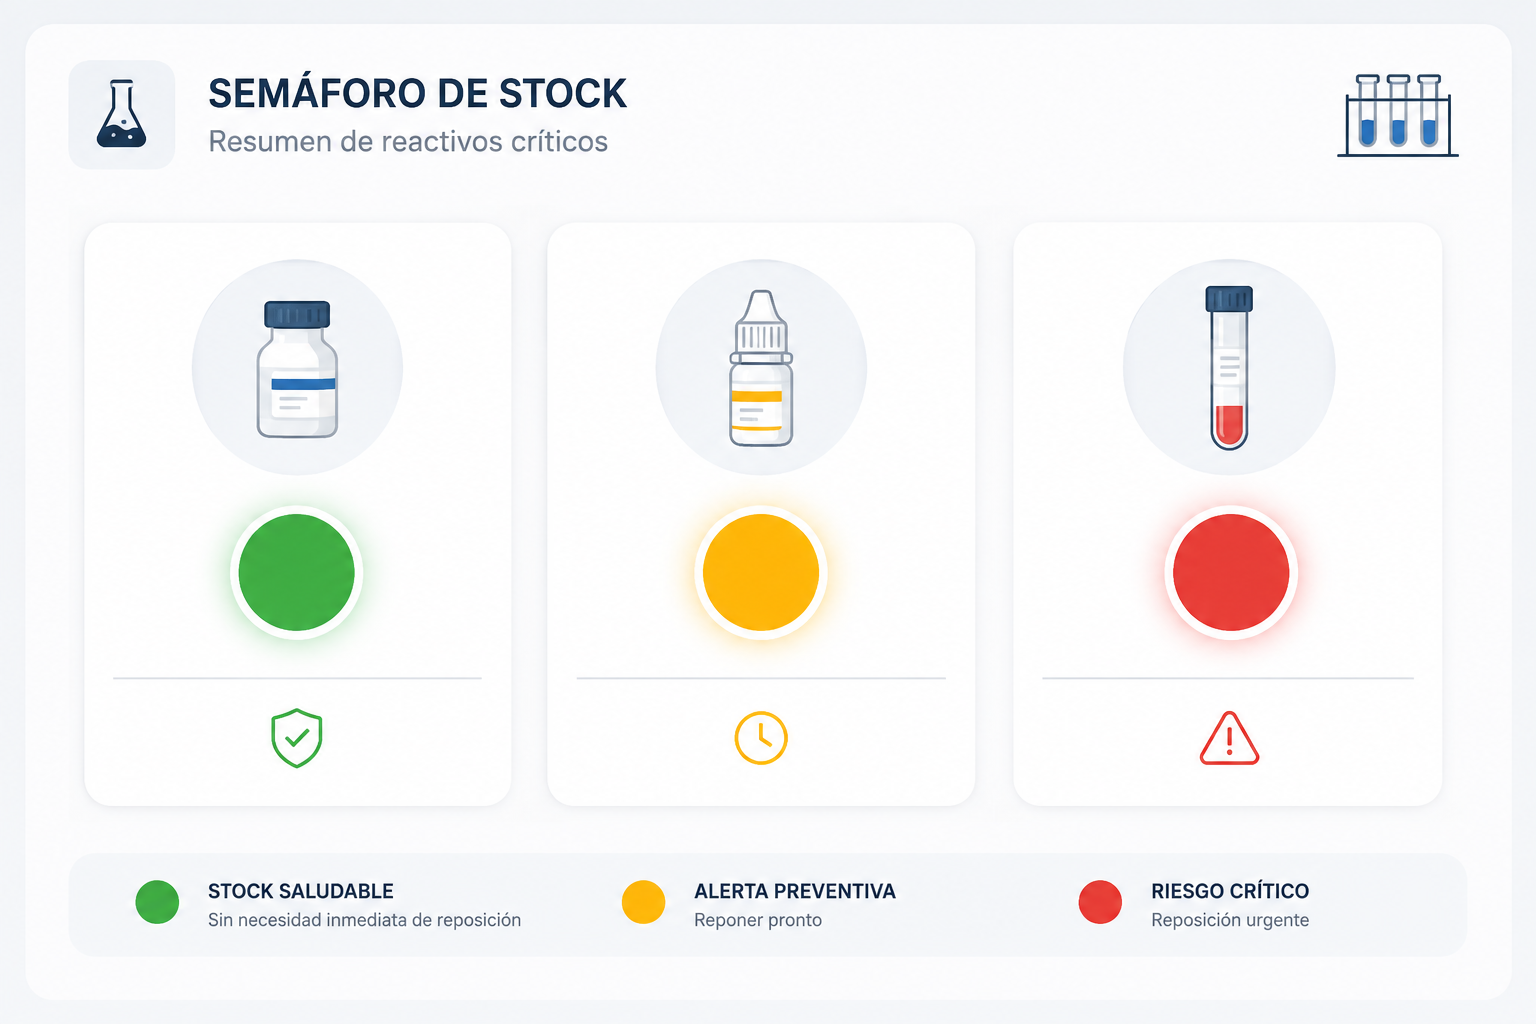

La imagen obtenida cumple con lo solicitado: un panel limpio y profesional, con tres estados claramente diferenciados por color e iconografía médica reconocible (frasco, gotero, tubo de ensayo), acompañado de una leyenda que explica cada nivel de alerta. Sirve como mockup fiel de cómo se vería el sistema de alertas si se implementara como panel de monitoreo real para el equipo del laboratorio.

## Resultados

La implementación logró resolver el objetivo planteado: transformar datos de consumo ya existentes en alertas tempranas claras y accionables, sin necesidad de desarrollo de software adicional.

- Los tres prompts (zero-shot, one-shot, few-shot) lograron calcular correctamente los días restantes de cada reactivo a partir del stock y el ritmo de consumo.
- Se identificó una diferencia relevante entre técnicas: el **zero-shot**, al no tener un criterio de umbral explícito, definió uno propio, lo que generó una clasificación distinta a la esperada para el reactivo GLUC3 (🔴 Rojo en lugar de 🟡 Amarillo). El **one-shot** y el **few-shot**, en cambio, replicaron consistentemente el criterio dado, coincidiendo entre sí.
- El **few-shot** fue la técnica más completa, ya que además de clasificar correctamente mostró el cálculo paso a paso, aportando trazabilidad — un atributo valioso para un sistema que deba ser auditado por el equipo del laboratorio.
- El prompt texto-imagen generó una infografía coherente con la propuesta visual planteada en la Preentrega 1, validando que la idea del "semáforo de stock" es representable de forma clara y profesional.

En conjunto, la solución sí logra llegar al resultado esperado: un mecanismo simple, sin desarrollo de software, capaz de convertir datos de consumo reales en alertas de riesgo clasificadas y visualmente comunicables.

## Conclusiones

El proyecto permitió validar que un problema operativo real del laboratorio — la falta de alertas tempranas ante posibles quiebres de stock — puede abordarse con generación de prompts, sin necesidad de desarrollo de software adicional ni de una API paga, usando únicamente datos que el laboratorio ya genera de forma rutinaria.

El hallazgo más relevante del proceso fue metodológico: comparar zero-shot, one-shot y few-shot sobre el mismo dataset mostró en la práctica que **la calidad de una solución basada en prompts depende directamente de qué tan explícito sea el criterio que se le da al modelo**. Sin ejemplos que fijen el umbral de riesgo, el modelo puede improvisar un criterio propio, lo que en un contexto real (donde las alertas deben ser confiables y auditables) representa un riesgo. Este hallazgo mejora directamente lo planteado en la Preentrega 1 y en la Entrega 2, donde el prompt de la Etapa 1 no especificaba cómo evitar esta ambigüedad.

Respecto a los objetivos propuestos:
- ✅ Se identificó una problemática real y se planteó una solución concreta usando ChatGPT para texto-texto y texto-imagen.
- ✅ Se planteó una solución factible, evaluando los recursos disponibles (datos reales del laboratorio, sin necesidad de infraestructura adicional).
- ✅ Se optimizó el uso de prompts, minimizando la cantidad de consultas (una por técnica comparada) y maximizando la consistencia del resultado mediante few-shot.

Como línea de continuidad, sería valioso incorporar el dato real de stock físico (no hipotético) e integrar el prompt de clasificación directamente sobre las planillas ya trabajadas en Excel/Power BI, para pasar de una prueba de concepto a una herramienta de uso diario en el laboratorio.

## Referencias

- Reportes "Contador de prueba detallado" del equipo analizador Cobas Pure (Roche/Hitachi), correspondientes a los cortes del 12/05/2026, 02/06/2026 y 01/07/2026.
- ChatGPT (OpenAI) — utilizado para la generación de los prompts texto-texto y texto-imagen de este proyecto.
- Material del curso "IA - Generación de Prompts" (Coderhouse), Módulo 4: Técnicas avanzadas de prompting I (zero-shot, one-shot, few-shot).